In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('11-iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [5]:
df['Species'].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [6]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

df['Species'] = encoder.fit_transform(df['Species'])
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,0
1,2,4.9,3.0,1.4,0.2,0
2,3,4.7,3.2,1.3,0.2,0
3,4,4.6,3.1,1.5,0.2,0
4,5,5.0,3.6,1.4,0.2,0


In [7]:
df.drop(columns = 'Id' , axis = 1 , inplace = True)

df['Species'] = df['Species'].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


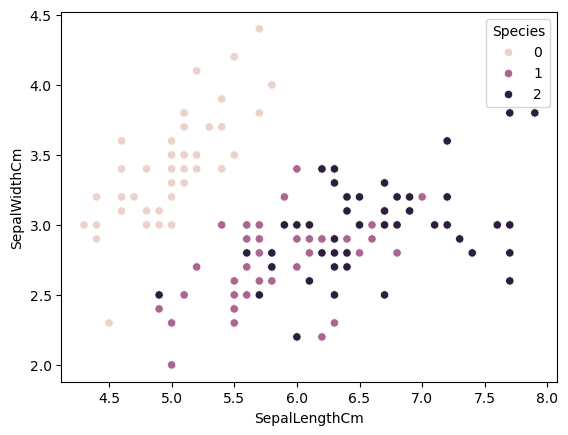

In [10]:
sns.scatterplot(data = df , x = 'SepalLengthCm' , y = 'SepalWidthCm' , hue = 'Species')
plt.show()

<Axes: xlabel='PetalLengthCm', ylabel='PetalWidthCm'>

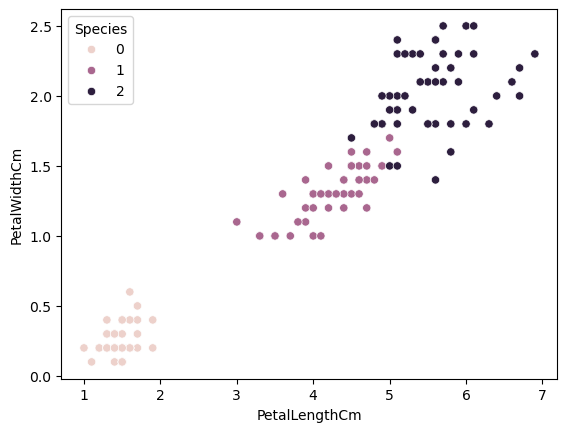

In [11]:
sns.scatterplot(data = df , x = 'PetalLengthCm' , y = 'PetalWidthCm' , hue = 'Species')

In [12]:
# Grafiklerdede gorundugu gibi dataları ayırmak kolay olacak zaten 150 tane data var çok da zor olmayacak

In [14]:
X =  df.drop(columns = 'Species' , axis = 1)
y = df['Species']

from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.25 , random_state = 15)


In [15]:
# Gauss yontemi kullanacağımız icin(cunku değerler surekli) scale etmemiz gerekli eğer bernulli veya multinomial kullansaydık scale etmeye gerek yoktu

In [16]:
from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()

In [20]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) 
X_test_scaled = scaler.transform(X_test)

gnb.fit(X_train_scaled , y_train) 

y_pred = gnb.predict(X_test_scaled)

from sklearn.metrics import accuracy_score , confusion_matrix , classification_report 

print('Accuracy Score : ' , accuracy_score(y_test , y_pred))
print('Classificaation Report : \n' , classification_report(y_test , y_pred))
print('Confusion Matrix : \n' , confusion_matrix(y_test , y_pred))

# %100 Doğru Çalışıyor

Accuracy Score :  1.0
Classificaation Report : 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38

Confusion Matrix : 
 [[12  0  0]
 [ 0 14  0]
 [ 0  0 12]]
